# Mall Customer Segmentation using K-Means Clustering
### A Step-by-Step Beginner-Friendly Machine Learning Project

This notebook guides you through using **K-Means Clustering** to segment mall customers based on their annual income and spending behaviors. We will follow a standard machine learning workflow, explaining every step along the way.

## Step 1: Importing Libraries
We import the tools we need for loading data, analyzing it, scaling, clustering, and plotting.

In [11]:
import pandas as pd  # Used to handle data in tabular format (DataFrames)
import numpy as np   # Used for numerical computations
import matplotlib.pyplot as plt  # Used to create static visualizations
import seaborn as sns  # Built on top of matplotlib, used for making beautiful graphics
from sklearn.preprocessing import StandardScaler  # Used to scale features to a similar range
from sklearn.cluster import KMeans  # The K-Means algorithm class
from sklearn.metrics import silhouette_score  # Metric to evaluate clustering quality

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Data Loading
We load the dataset directly from a public raw CSV URL using Pandas.

In [12]:
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 3: Basic Exploratory Data Analysis (EDA)
Let's check the size of our dataset and look for any missing values to understand our data better.

In [13]:
print(f"Dataset Shape (Rows, Columns): {df.shape}\n")

print("Missing values in each column:")
print(df.isnull().sum())

print("\nBasic Summary Statistics:")
df.describe()

Dataset Shape (Rows, Columns): (200, 5)

Missing values in each column:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Basic Summary Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Step 4: Preprocessing & Feature Selection
We choose **Annual Income** (column index 3) and **Spending Score** (column index 4) for our clustering. This is a classic 2D feature set that shows clean customer segments.

In [14]:
X = df.iloc[:, [3, 4]].values
print("First 5 rows of our selected features (Income & Spending Score):")
print(X[:5])

First 5 rows of our selected features (Income & Spending Score):
[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


## Step 5: Feature Scaling
Since K-Means calculates distance between points, features with large numbers (like income, up to 137k) will overpower features with small numbers (like score, 1-100). We standardize the data so it has a mean of 0 and variance of 1.

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("First 5 rows of scaled features:")
print(X_scaled[:5])

First 5 rows of scaled features:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


## Step 6: Elbow Method (Finding Optimal K)
We calculate the Within-Cluster Sum of Squares (WCSS/Inertia) for values of $K$ from 1 to 10 and plot them to find the "elbow" point.

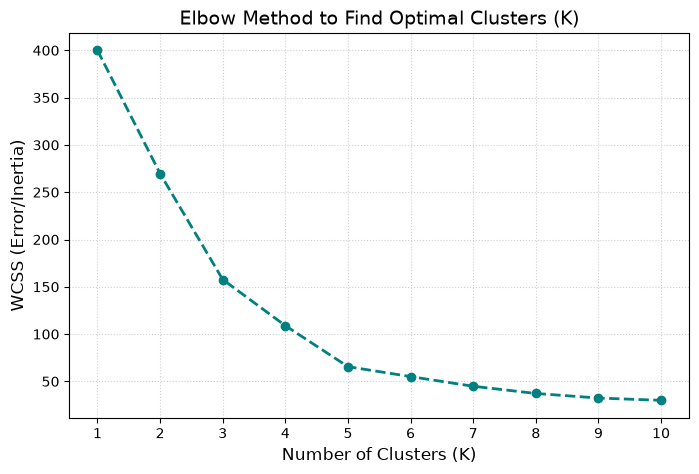

In [16]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='teal', linewidth=2)
plt.title('Elbow Method to Find Optimal Clusters (K)', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Error/Inertia)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Step 7: K-Means Model Training
From the elbow plot, the decrease in WCSS slows down significantly after $K=5$. We train our model on $K=5$ clusters and label each customer.

In [17]:
optimal_k = 5
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
y_clusters = kmeans_model.fit_predict(X_scaled)

# Add the cluster label back to our original DataFrame for interpretation
df['Cluster'] = y_clusters
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Step 8: Silhouette Score
Let's measure how well-separated our clusters are. A score above 0.5 indicates a strong clustering structure.

In [18]:
sil_score = silhouette_score(X_scaled, y_clusters)
print(f"Silhouette Score for K=5 is: {sil_score:.4f}")

Silhouette Score for K=5 is: 0.5547


## Step 9: Cluster Visualization
We plot the data points colored by their cluster label and mark the centroids with a black 'X'.

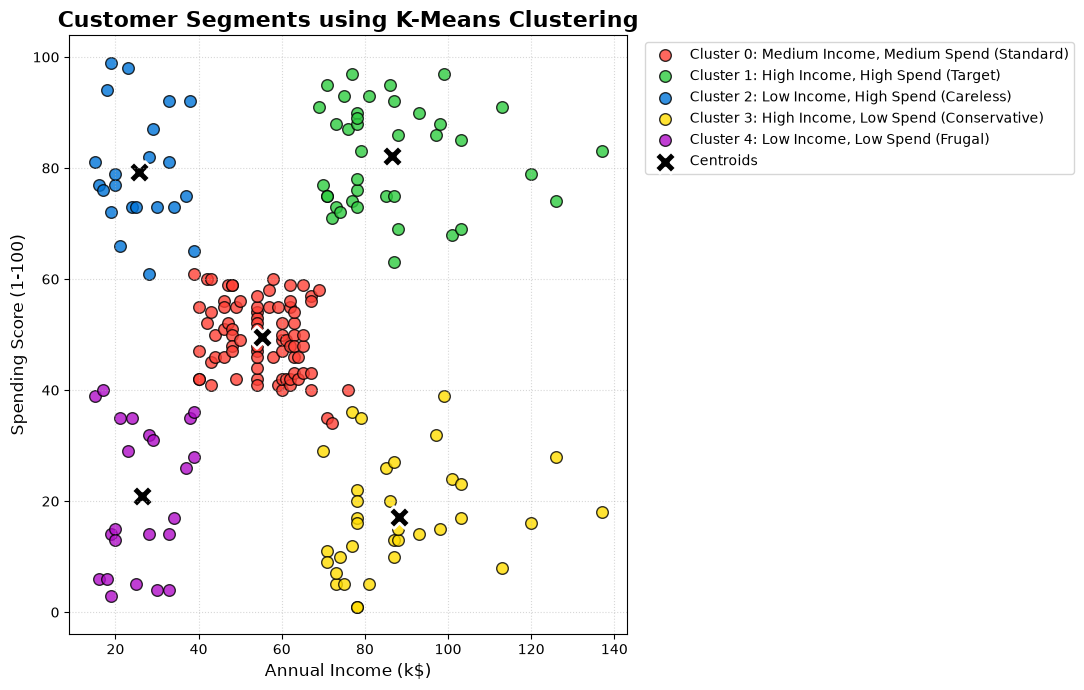

In [19]:
plt.figure(figsize=(11, 7))

# Find original scale centroids
centroids = scaler.inverse_transform(kmeans_model.cluster_centers_)

# Dynamically assign labels based on centroids' average values
cluster_labels = {}
for i in range(optimal_k):
    income = centroids[i, 0]
    spend = centroids[i, 1]
    
    if income < 40 and spend > 60:
        desc = "Low Income, High Spend (Careless)"
    elif income > 70 and spend > 60:
        desc = "High Income, High Spend (Target)"
    elif income > 70 and spend < 40:
        desc = "High Income, Low Spend (Conservative)"
    elif income < 40 and spend < 40:
        desc = "Low Income, Low Spend (Frugal)"
    else:
        desc = "Medium Income, Medium Spend (Standard)"
        
    cluster_labels[i] = f"Cluster {i}: {desc}"

# Define colors
colors = ['#FF4136', '#2ECC40', '#0074D9', '#FFDC00', '#B10DC9']

for i in range(optimal_k):
    plt.scatter(X[y_clusters == i, 0], X[y_clusters == i, 1], 
                s=70, c=colors[i], label=cluster_labels[i], alpha=0.8, edgecolors='black')

# Centroids
plt.scatter(centroids[:, 0], centroids[:, 1], 
            s=250, c='black', marker='X', label='Centroids', edgecolors='white', linewidth=2)

plt.title('Customer Segments using K-Means Clustering', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Step 10: Interpretation of Customer Segments
Let's view the average statistics for each cluster to understand each customer group.

In [20]:
print("Interpretation of Customer Segments:")
for i in range(optimal_k):
    cluster_subset = df[df['Cluster'] == i]
    mean_income = cluster_subset['Annual Income (k$)'].mean()
    mean_spending = cluster_subset['Spending Score (1-100)'].mean()
    count = len(cluster_subset)
    print(f"\n{cluster_labels[i]}:")
    print(f"  - Count: {count} customers")
    print(f"  - Avg Annual Income: ${mean_income:.1f}k")
    print(f"  - Avg Spending Score: {mean_spending:.1f}/100")

Interpretation of Customer Segments:

Cluster 0: Medium Income, Medium Spend (Standard):
  - Count: 81 customers
  - Avg Annual Income: $55.3k
  - Avg Spending Score: 49.5/100

Cluster 1: High Income, High Spend (Target):
  - Count: 39 customers
  - Avg Annual Income: $86.5k
  - Avg Spending Score: 82.1/100

Cluster 2: Low Income, High Spend (Careless):
  - Count: 22 customers
  - Avg Annual Income: $25.7k
  - Avg Spending Score: 79.4/100

Cluster 3: High Income, Low Spend (Conservative):
  - Count: 35 customers
  - Avg Annual Income: $88.2k
  - Avg Spending Score: 17.1/100

Cluster 4: Low Income, Low Spend (Frugal):
  - Count: 23 customers
  - Avg Annual Income: $26.3k
  - Avg Spending Score: 20.9/100
